<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 5: Digital Logic</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part II: Devices & Circuits — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

1. [SFQ Logic Overview](#1-sfq-overview)
2. [RSFQ/ERSFQ for I/O](#2-rsfq-ersfq)
3. [AQFP Fundamentals](#3-aqfp-fundamentals)
4. [The Majority Gate](#4-majority-gate)
5. [Derived Gates](#5-derived-gates)
6. [Four-Phase Clocking](#6-clocking)
7. [Design Methodology](#7-design-methodology)
   - [7b. Standard Cell Library](#7b-standard-cell-library)
   - [7c. Design Examples](#7c-design-examples)
   - [7d. Layout Considerations](#7d-layout-considerations)
   - [7e. Flux Trapping](#7e-flux-trapping)
8. [Performance Comparison](#8-performance)
9. [System Architecture](#9-system-architecture)

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

- Explain the physical basis of Single Flux Quantum (SFQ) logic
- Understand why AQFP achieves ultra-low power consumption
- Design combinational logic using majority gates
- Apply four-phase clocking and path balancing rules
- Articulate when to use *SFQ vs AQFP in system design
- **Understand standard cell library components and characterization**
- **Design basic circuits (MUX, full adder) in majority logic**
- **Identify key layout considerations for AQFP cells**

---

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'aqfp': '#00BCD4',
    'rsfq': '#9C27B0',
    'phase0': '#E3F2FD',
    'phase1': '#BBDEFB',
    'phase2': '#90CAF9',
    'phase3': '#64B5F6'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Physical constants
Phi_0 = 2.067833848e-15  # Wb (flux quantum)
k_B = 1.380649e-23       # J/K (Boltzmann constant)

print("Setup complete.")

Setup complete.


---
<a id="1-sfq-overview"></a>
# 1. SFQ Logic Overview
---

**Single Flux Quantum (SFQ)** logic represents information using the fundamental unit of magnetic flux:

$$\Phi_0 = \frac{h}{2e} = 2.07 \times 10^{-15} \text{ Wb} = 2.07 \text{ mV}\cdot\text{ps}$$

### SFQ Pulse Representation

Due to flux quantization in superconducting loops, voltage pulses have a precisely quantized area:

$$\int V(t)\,dt = \Phi_0$$

| Parameter | Typical Value |
|-----------|---------------|
| Pulse width | 1-2 ps |
| Pulse amplitude | ~1-2 mV |
| Pulse area | 2.07 mV·ps (fixed) |

### Logic Families

| Family | Bias | Static Power | Speed | Energy/op | Primary Use |
|--------|------|-------------|-------|-----------|-------------|
| **RSFQ** | DC resistors | High | >50 GHz | ~0.2 aJ | Legacy, high-speed |
| **ERSFQ** | DC inductors | Low | >50 GHz | ~0.02 aJ | Efficient digital |
| **AQFP** | AC excitation | **Zero** | 5-10 GHz | **~1.4 zJ** | **Ultra-low power** |

**Note**: RSFQ is 100× higher energy than AQFP. After 1000× cooling overhead, RSFQ is roughly same as CMOS.

**This course focuses on AQFP** for digital design, with *SFQ used for I/O interfaces.

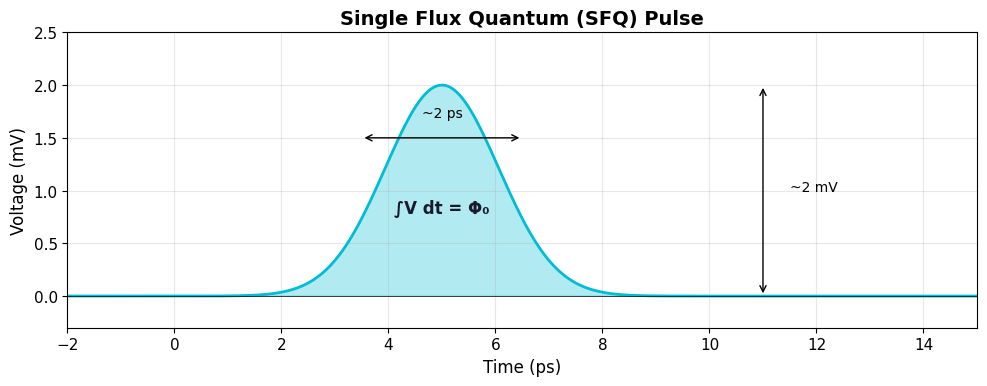

Pulse area = Φ₀ = 2.07 fWb = 2.07 mV·ps


In [2]:
# Visualize: SFQ pulse
fig, ax = plt.subplots(figsize=(10, 4))

# Generate Gaussian-like SFQ pulse
t = np.linspace(-5, 15, 1000)  # ps
pulse_width = 1.5  # ps
t0 = 5  # pulse center

# Gaussian derivative (more realistic pulse shape)
V = 2.0 * np.exp(-((t - t0)/pulse_width)**2)  # mV

ax.fill_between(t, V, alpha=0.3, color=COLORS['aqfp'])
ax.plot(t, V, color=COLORS['aqfp'], linewidth=2)
ax.axhline(0, color='black', linewidth=0.5)

# Annotations
ax.annotate('', xy=(t0 + pulse_width, 1.5), xytext=(t0 - pulse_width, 1.5),
            arrowprops=dict(arrowstyle='<->', color='black'))
ax.text(t0, 1.7, '~2 ps', ha='center', fontsize=10)

ax.annotate('', xy=(11, 2.0), xytext=(11, 0),
            arrowprops=dict(arrowstyle='<->', color='black'))
ax.text(11.5, 1.0, '~2 mV', ha='left', fontsize=10)

# Shaded area annotation
ax.text(t0, 0.8, '∫V dt = Φ₀', ha='center', fontsize=12, 
        color=COLORS['dark'], fontweight='bold')

ax.set_xlabel('Time (ps)', fontsize=12)
ax.set_ylabel('Voltage (mV)', fontsize=12)
ax.set_title('Single Flux Quantum (SFQ) Pulse', fontsize=14, fontweight='bold')
ax.set_xlim(-2, 15)
ax.set_ylim(-0.3, 2.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pulse area = Φ₀ = {Phi_0*1e15:.2f} fWb = 2.07 mV·ps")

---
<a id="2-rsfq-ersfq"></a>
# 2. RSFQ/ERSFQ for I/O
---

While AQFP is our primary logic family, **RSFQ/ERSFQ** circuits are essential for I/O interfaces due to their higher speed and natural asynchronous operation.

### When to Use *SFQ

| Application | Why *SFQ | Trade-off |
|-------------|---------|----------|
| **PTL drivers/receivers** | High speed, impedance matching | Higher power |
| **Async counters** | No clock needed, event-driven | Power scales with rate |
| **Async FIFOs** | Clock domain crossing | Complexity at boundaries |

### PTL (Passive Transmission Line) Interconnects

For chip-to-chip or long-distance on-chip communication:
- **PTL drivers** launch SFQ pulses onto transmission lines
- **PTL receivers** capture and restore pulses
- Demonstrated: **117 Gbps** chip-to-chip with error rate <10⁻¹⁵

### Asynchronous FIFOs

- Bridge between different clock domains
- Handle data rate mismatches
- **Critical for interfacing AQFP core with high-speed I/O**

### Key Insight

> **Use *SFQ at the edges for I/O, AQFP in the core for computation.**

---
<a id="3-aqfp-fundamentals"></a>
# 3. AQFP Fundamentals
---

**Adiabatic Quantum-Flux-Parametron (AQFP)** is an ultra-low-power superconducting logic family operating at 4.2 K.

### What Makes AQFP Special

| Property | Value | Significance |
|----------|-------|-------------|
| Operating temperature | 4.2 K | Liquid helium |
| Switching energy | **~1.4 zJ/JJ at 5 GHz** | 100,000× lower than CMOS (device level) |
| Clock frequency | 2.5-10 GHz | MANA runs at 2.5 GHz |
| Static power | **Zero** | No DC bias resistors |
| System-level efficiency | **~100× vs CMOS** | After cooling overhead |
| Logic basis | Majority gates | Different from AND/OR |

### Adiabatic Switching

The key to AQFP's efficiency is **adiabatic switching**:

1. The potential energy landscape transitions **gradually** from single-well to double-well
2. The system tracks its energy minimum (quasi-static process)
3. Energy is **borrowed from the clock and returned**, not dissipated
4. Switching energy can be arbitrarily reduced by slowing the transition

### AC Excitation (No DC Bias)

Unlike RSFQ which uses DC bias through resistors:
- AQFP uses **sinusoidal AC excitation** currents
- Excitation serves as **both clock and power supply**
- **Zero static power dissipation**

### State Representation

Binary states are encoded as:
- **Flux quantum position** in left or right loop of a DC SQUID
- Equivalently: **circulating current direction** (clockwise vs counterclockwise)
- Logic "1" = positive circulating current
- Logic "0" = negative circulating current

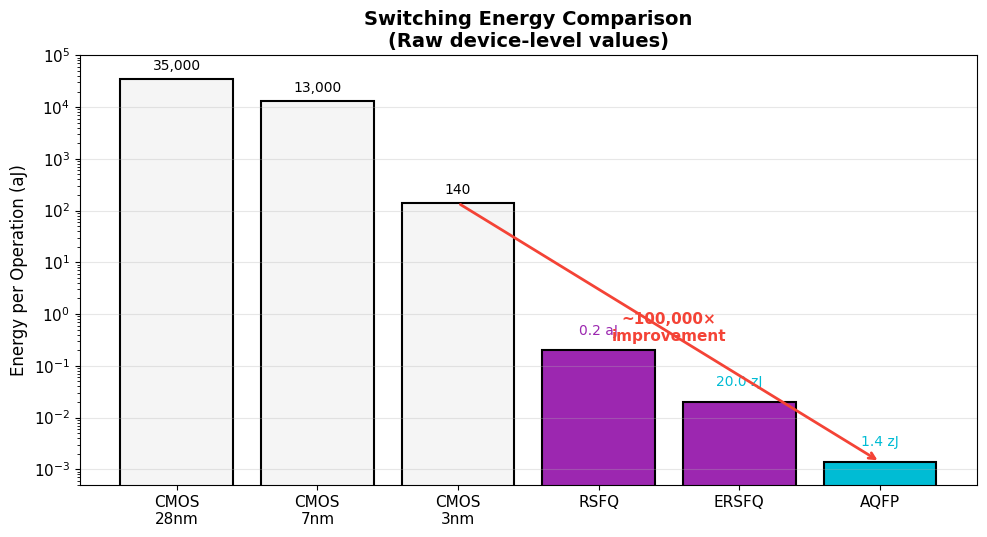

AQFP switching energy: 1.4 zJ = 0.0014 aJ (zeptojoules)
RSFQ switching energy: 0.2 aJ (100× higher than AQFP)
At 4.2 K: kT = 0.1 zJ
AQFP operates at ~24 kT per junction


In [3]:
# Energy comparison
fig, ax = plt.subplots(figsize=(10, 5.5))

technologies = ['CMOS\n28nm', 'CMOS\n7nm', 'CMOS\n3nm', 'RSFQ', 'ERSFQ', 'AQFP']
energies_aJ = [35000, 13000, 140, 0.2, 0.02, 0.0014]  # attojoules; RSFQ = 0.2 aJ, AQFP = 1.4 zJ = 0.0014 aJ
colors = [COLORS['light'], COLORS['light'], COLORS['light'], COLORS['rsfq'], 
          COLORS['rsfq'], COLORS['aqfp']]

bars = ax.bar(technologies, energies_aJ, color=colors, edgecolor='black', linewidth=1.5)
ax.set_yscale('log')
ax.set_ylabel('Energy per Operation (aJ)', fontsize=12)
ax.set_title('Switching Energy Comparison\n(Raw device-level values)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0.0005, 100000)
ax.grid(True, alpha=0.3, axis='y')

# Annotate
for bar, energy in zip(bars, energies_aJ):
    if energy >= 100:
        ax.text(bar.get_x() + bar.get_width()/2, energy * 1.5, 
                f'{energy:,.0f}', ha='center', fontsize=10)
    elif energy >= 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, energy * 2, 
                f'{energy:.1f} aJ', ha='center', fontsize=10, color=COLORS['rsfq'])
    else:
        ax.text(bar.get_x() + bar.get_width()/2, energy * 2, 
                f'{energy*1000:.1f} zJ', ha='center', fontsize=10, color=COLORS['aqfp'])

# Highlight improvement
ax.annotate('', xy=(5, 0.0014), xytext=(2, 140),
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
ax.text(3.5, 0.3, '~100,000×\nimprovement', fontsize=11, ha='center', 
        color=COLORS['danger'], fontweight='bold')

plt.tight_layout()
plt.show()

print(f"AQFP switching energy: 1.4 zJ = 0.0014 aJ (zeptojoules)")
print(f"RSFQ switching energy: 0.2 aJ (100× higher than AQFP)")
print(f"At 4.2 K: kT = {k_B * 4.2 * 1e21:.1f} zJ")
print(f"AQFP operates at ~{1.4e-21 / (k_B * 4.2):.0f} kT per junction")

---
<a id="4-majority-gate"></a>
# 4. The Majority Gate
---

AQFP uses **majority logic**, not AND/OR. The fundamental gate is:

$$\text{MAJ}(a, b, c) = ab + bc + ca$$

The output is "1" if **at least two of three inputs** are "1".

### Truth Table

| a | b | c | MAJ(a,b,c) |
|---|---|---|------------|
| 0 | 0 | 0 | 0 |
| 0 | 0 | 1 | 0 |
| 0 | 1 | 0 | 0 |
| 0 | 1 | 1 | **1** |
| 1 | 0 | 0 | 0 |
| 1 | 0 | 1 | **1** |
| 1 | 1 | 0 | **1** |
| 1 | 1 | 1 | **1** |

### Circuit Structure

A 3-input majority gate consists of:
- **3 input buffers** (2 JJ each) → 6 JJ
- **1 output buffer** (implicit in merger)
- **Total: 6 Josephson junctions**

### Why Majority Logic?

1. **Natural fit** for AQFP's magnetic coupling
2. **Efficient arithmetic**: Full adder = 2 MAJ gates
3. **Inverters are free**: Just flip the output coupling polarity

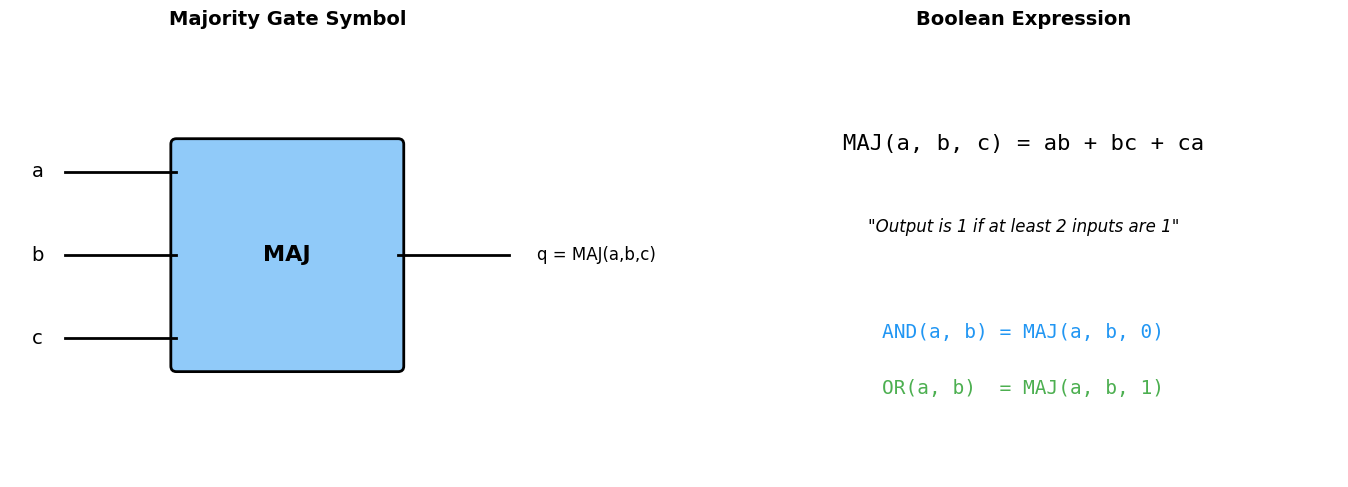

In [4]:
# Visualize majority gate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Circuit symbol
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Majority Gate Symbol', fontsize=14, fontweight='bold')

# Draw MAJ box
maj_box = FancyBboxPatch((3, 2), 4, 4, boxstyle="round,pad=0.1",
                          facecolor=COLORS['phase2'], edgecolor='black', linewidth=2)
ax1.add_patch(maj_box)
ax1.text(5, 4, 'MAJ', ha='center', va='center', fontsize=16, fontweight='bold')

# Inputs
for i, (y, label) in enumerate([(5.5, 'a'), (4, 'b'), (2.5, 'c')]):
    ax1.plot([1, 3], [y, y], 'k-', linewidth=2)
    ax1.text(0.5, y, label, ha='center', va='center', fontsize=14)

# Output
ax1.plot([7, 9], [4, 4], 'k-', linewidth=2)
ax1.text(9.5, 4, 'q = MAJ(a,b,c)', ha='left', va='center', fontsize=12)

# Right: Boolean expression
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.axis('off')
ax2.set_title('Boolean Expression', fontsize=14, fontweight='bold')

ax2.text(5, 6, 'MAJ(a, b, c) = ab + bc + ca', ha='center', va='center', 
         fontsize=16, fontfamily='monospace')
ax2.text(5, 4.5, '"Output is 1 if at least 2 inputs are 1"', 
         ha='center', va='center', fontsize=12, style='italic')

# Derive AND and OR
ax2.text(5, 2.5, 'AND(a, b) = MAJ(a, b, 0)', ha='center', fontsize=14, 
         fontfamily='monospace', color=COLORS['primary'])
ax2.text(5, 1.5, 'OR(a, b)  = MAJ(a, b, 1)', ha='center', fontsize=14,
         fontfamily='monospace', color=COLORS['success'])

plt.tight_layout()
plt.show()

---
<a id="5-derived-gates"></a>
# 5. Derived Gates
---

All standard logic gates can be built from majority gates and inverters:

| Gate | Implementation | JJ Count |
|------|---------------|----------|
| **Buffer** | Direct connection (2 JJ cell) | 2 |
| **Inverter** | Buffer with negative coupling | 2 |
| **AND** | MAJ(a, b, 0) | 6 |
| **OR** | MAJ(a, b, 1) | 6 |
| **NAND** | MAJ(a, b, 0) with inverted output | 6 |
| **NOR** | MAJ(a, b, 1) with inverted output | 6 |
| **XOR** | Requires multiple MAJ gates | 18-24 |
| **Splitter** | 1-to-4 fan-out | 2 |

### Inverters Are Free

Inversion is achieved by **reversing the output transformer coupling polarity**. This requires no additional Josephson junctions—just a different winding direction in the layout.

### Fan-Out Requires Splitters

**Critical rule**: Every AQFP gate has fan-out of exactly **1**.

To drive N inputs, you need a **splitter tree** with (N-1) splitter cells:

```mermaid
flowchart LR
    input --> SPL1[SPL]
    SPL1 --> out1[output 1]
    SPL1 --> SPL2[SPL]
    SPL2 --> out2[output 2]
    SPL2 --> out3[output 3]

    style SPL1 fill:#FFF9C4
    style SPL2 fill:#FFF9C4
```

For fan-out of 3, you need 2 splitters (N-1 rule).

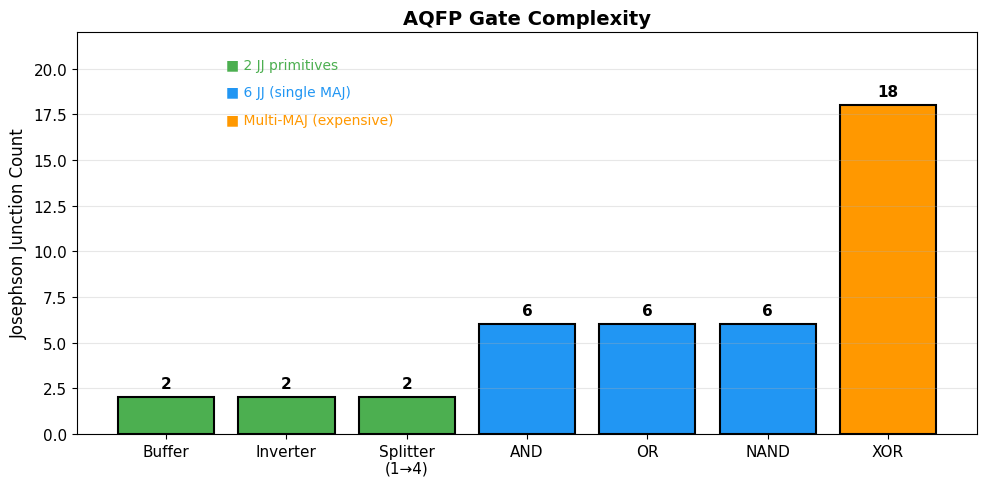

Key insight: XOR is expensive in majority logic (3 MAJ gates).
Design with MAJ gates directly when possible, not via XOR decomposition.


In [5]:
# JJ count comparison
fig, ax = plt.subplots(figsize=(10, 5))

gates = ['Buffer', 'Inverter', 'Splitter\n(1→4)', 'AND', 'OR', 'NAND', 'XOR']
jj_counts = [2, 2, 2, 6, 6, 6, 18]
colors_list = [COLORS['success'], COLORS['success'], COLORS['success'],
               COLORS['primary'], COLORS['primary'], COLORS['primary'],
               COLORS['secondary']]

bars = ax.bar(gates, jj_counts, color=colors_list, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Josephson Junction Count', fontsize=12)
ax.set_title('AQFP Gate Complexity', fontsize=14, fontweight='bold')
ax.set_ylim(0, 22)
ax.grid(True, alpha=0.3, axis='y')

# Annotate
for bar, jj in zip(bars, jj_counts):
    ax.text(bar.get_x() + bar.get_width()/2, jj + 0.5, str(jj), 
            ha='center', fontsize=11, fontweight='bold')

# Legend
ax.text(0.5, 20, '■ 2 JJ primitives', color=COLORS['success'], fontsize=10)
ax.text(0.5, 18.5, '■ 6 JJ (single MAJ)', color=COLORS['primary'], fontsize=10)
ax.text(0.5, 17, '■ Multi-MAJ (expensive)', color=COLORS['secondary'], fontsize=10)

plt.tight_layout()
plt.show()

print("Key insight: XOR is expensive in majority logic (3 MAJ gates).")
print("Design with MAJ gates directly when possible, not via XOR decomposition.")

---
<a id="6-clocking"></a>
# 6. Four-Phase Clocking
---

AQFP uses **four-phase AC excitation** for pipelined operation:

| Phase | Offset | Role |
|-------|--------|------|
| φ₁ | 0° | Row 0, 4, 8, ... |
| φ₂ | 90° | Row 1, 5, 9, ... |
| φ₃ | 180° | Row 2, 6, 10, ... |
| φ₄ | 270° | Row 3, 7, 11, ... |

### Key Rules

1. **Row number determines phase**: `phase = row % 4`
2. **Data flows from phase N to (N+1) mod 4**
3. **All cells in a row share the same clock phase**
4. **Every gate = one pipeline stage** (~50 ps latency at 5 GHz)

### Timing Constraints

- **Setup time**: Input must arrive before excitation rises
- **Hold time**: Input must remain stable through switching
- **Path balancing**: All paths to a gate must have **equal delay**

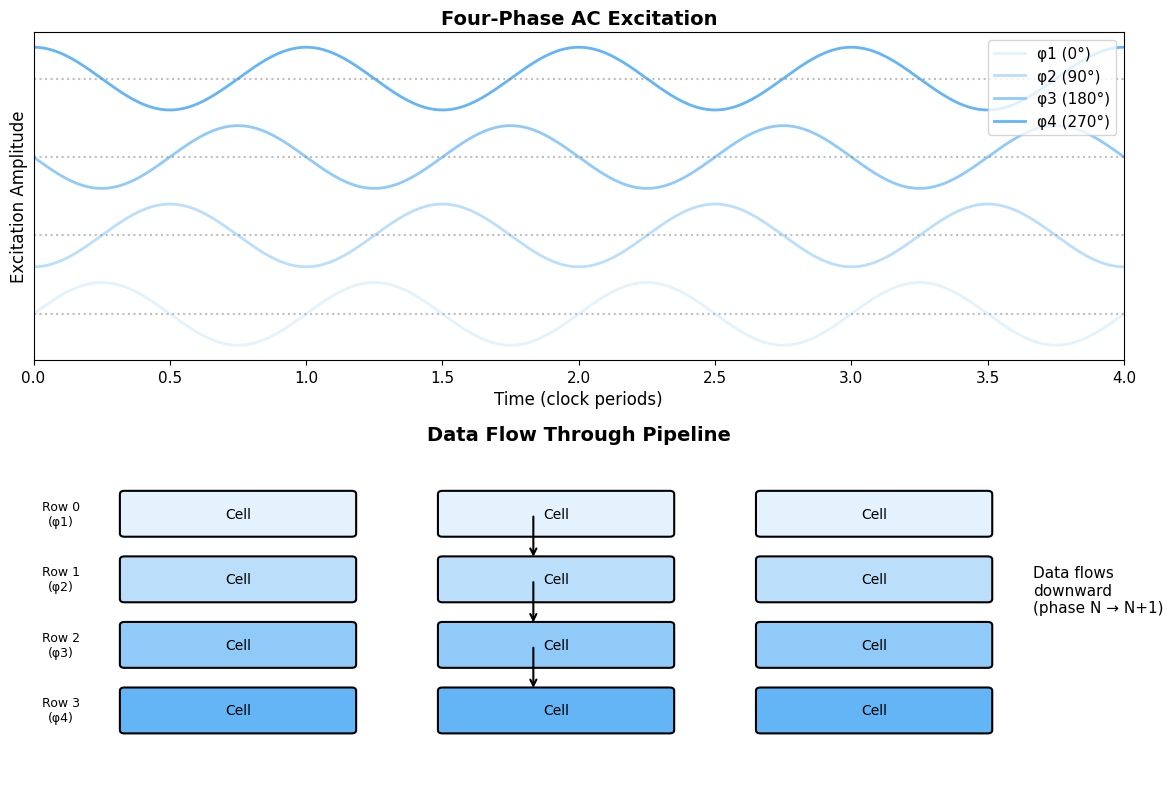

In [6]:
# Visualize 4-phase clocking
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top: Clock waveforms
t = np.linspace(0, 4, 1000)  # clock periods
phases = [0, 90, 180, 270]
phase_colors = [COLORS['phase0'], COLORS['phase1'], COLORS['phase2'], COLORS['phase3']]

for i, (phase, color) in enumerate(zip(phases, phase_colors)):
    signal = np.sin(2 * np.pi * t - np.radians(phase))
    ax1.plot(t, signal + i * 2.5, color=color, linewidth=2, label=f'φ{i+1} ({phase}°)')
    ax1.axhline(i * 2.5, color='gray', linestyle=':', alpha=0.5)

ax1.set_xlabel('Time (clock periods)', fontsize=12)
ax1.set_ylabel('Excitation Amplitude', fontsize=12)
ax1.set_title('Four-Phase AC Excitation', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_xlim(0, 4)
ax1.set_yticks([])

# Bottom: Pipeline diagram
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 5)
ax2.axis('off')
ax2.set_title('Data Flow Through Pipeline', fontsize=14, fontweight='bold')

# Draw rows
for row in range(4):
    phase = row % 4
    color = phase_colors[phase]
    y = 4 - row
    
    # Row boxes
    for col in range(3):
        x = 1 + col * 3.5
        rect = FancyBboxPatch((x, y - 0.3), 2.5, 0.6, boxstyle="round,pad=0.05",
                              facecolor=color, edgecolor='black', linewidth=1.5)
        ax2.add_patch(rect)
        ax2.text(x + 1.25, y, f'Cell', ha='center', va='center', fontsize=10)
    
    # Row label
    ax2.text(0.3, y, f'Row {row}\n(φ{phase+1})', ha='center', va='center', fontsize=9)

# Data flow arrows
ax2.annotate('', xy=(5.5, 3.3), xytext=(5.5, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax2.annotate('', xy=(5.5, 2.3), xytext=(5.5, 3.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax2.annotate('', xy=(5.5, 1.3), xytext=(5.5, 2.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax2.text(11, 2.5, 'Data flows\ndownward\n(phase N → N+1)', fontsize=11, ha='left')

plt.tight_layout()
plt.show()

---
<a id="7-design-methodology"></a>
# 7. Design Methodology
---

### Design Flow

```mermaid
flowchart LR
    A[Verilog RTL] --> B[Synthesis<br/>Yosys]
    B --> C[MIG<br/>Optimization]
    C --> D[AQFP<br/>Mapping]
    D --> E[Placement]
    E --> F[Routing]
    F --> G[GDS]

    style A fill:#E3F2FD
    style G fill:#C8E6C9
```

### Technology Mapping

1. Convert RTL to **And-Inverter Graph (AIG)**
2. Transform to **Majority-Inverter Graph (MIG)**
3. Map MIG nodes to AQFP cells (BUF, INV, MAJ3)
4. Insert **splitters** for fan-out > 1

### Path Balancing (Critical!)

All paths converging at a gate **must have equal delay**:

```mermaid
flowchart LR
    a --> BUF1[BUF] --> BUF2[BUF] --> MAJ
    b --> BUF3[BUF] --> BUF4[BUF] --> MAJ
    MAJ --> q

    style MAJ fill:#90CAF9
```

If path `a` has 2 buffers and path `b` has 0, you must add 2 buffers to path `b`.

> **Buffer overhead can be 50-90% of total circuit area!**

### Wire Length Constraint

Wire length limits depend on **inductance** (affects signal current):
- Auto-routing typically uses **~100 µm** max wire length
- Wider wires have lower inductance → can extend to **~1 mm**
- Beyond these limits: signal current attenuates excessively
- Insert **buffer cells as repeaters** for longer routes

### Margin Analysis

- Excitation amplitude margins: ±19-26%
- Inductance variation tolerance
- Monte Carlo simulation with thermal noise

---
<a id="7b-standard-cell-library"></a>
# 7b. Standard Cell Library
---

A **standard cell library** is the foundation of digital design. For AQFP, the library is relatively small but carefully characterized.

### Core Cell Types

| Cell | Function | JJ Count | Pipeline Stages | Notes |
|------|----------|----------|-----------------|-------|
| **BUF** | Buffer/repeater | 2 | 1 | Identity function, signal regeneration |
| **INV** | Inverter | 2 | 1 | Negative coupling transformer |
| **SPL** | 1→2 Splitter | 2 | 1 | Fan-out; tree for higher fan-out |
| **MAJ3** | 3-input majority | 6 | 1 | Core compute primitive |
| **CONST0** | Logic 0 | 2 | 1 | Tied to ground reference |
| **CONST1** | Logic 1 | 2 | 1 | Tied to Φ₀ reference |

### Cell Characterization

Each cell is characterized for:

1. **Timing**
   - **Propagation delay**: ~10 ps per stage (process-dependent)
   - **Setup time**: Input stable before excitation rise
   - **Hold time**: Input stable through switching window

2. **Operating margins**
   - Excitation amplitude: nominal ± 20-25%
   - Temperature sensitivity: characterized at 4.2 K
   - Bias current margins (for *SFQ cells)

3. **Layout parameters**
   - Cell dimensions (width × height)
   - Pin locations for routing
   - Power rail positions (excitation lines)

### Physical Cell Structure: AQFP Buffer

```mermaid
flowchart TB
    subgraph cell[AQFP Buffer Cell<br/><i>10-20 µm × 5-10 µm</i>]
        direction TB
        EX[═══ Excitation Line AC ═══]
        
        subgraph core[" "]
            direction LR
            IN[Input<br/>Xfmr] --> JJ1((JJ₁))
            JJ1 --> JJ2((JJ₂))
            JJ2 --> OUT[Output<br/>Xfmr]
        end
        
        GND[═══ Ground ═══]
        
        EX --- JJ1
        EX --- JJ2
        JJ1 --- GND
        JJ2 --- GND
    end

    style JJ1 fill:#FF9800,stroke:#E65100,stroke-width:2px
    style JJ2 fill:#FF9800,stroke:#E65100,stroke-width:2px
    style EX fill:#90CAF9
    style GND fill:#757575,color:#fff
```

### The MAJ3 Cell in Detail

The majority gate is the computational workhorse:

```mermaid
flowchart LR
    subgraph maj3[MAJ3 Cell]
        direction TB
        subgraph inputs[Input Buffers]
            direction TB
            JJa((JJ)) 
            JJb((JJ))
            JJc((JJ))
        end
        inputs --> M((Merger<br/>Node))
        M --> OUT[Output]
    end
    
    A[Input A] --> JJa
    B[Input B] --> JJb
    C[Input C] --> JJc

    style M fill:#4CAF50,stroke:#2E7D32,stroke-width:2px
    style JJa fill:#FF9800
    style JJb fill:#FF9800
    style JJc fill:#FF9800
```

The three input currents sum at a **merger node**. The output takes the sign of the majority:
- 2 or 3 positive → positive output (logic 1)
- 2 or 3 negative → negative output (logic 0)

---
<a id="8-performance"></a>
# 8. Performance Comparison
---

---
<a id="7c-design-examples"></a>
# 7c. Design Examples
---

Let's walk through designing common circuits in AQFP, showing how to think in majority logic.

---

## Example 1: 2-to-1 Multiplexer

**Specification**: `Y = S ? B : A` (select between A and B based on S)

**Boolean expression**: `Y = S·B + S̄·A`

**Majority implementation**:
$$Y = \text{MAJ}(\text{MAJ}(S, B, 0), \text{MAJ}(\bar{S}, A, 0), 1)$$

Breaking this down:
- `MAJ(S, B, 0)` = S AND B
- `MAJ(S̄, A, 0)` = (NOT S) AND A  
- Outer MAJ with const 1 = OR of the two terms

```mermaid
flowchart LR
    subgraph mux[2:1 MUX — 24 JJ, 4 stages]
        S --> BUF[BUF] --> SPL[SPL]
        SPL --> MAJ1[MAJ]
        SPL --> INV[INV] --> MAJ2[MAJ]
        B --> MAJ1
        C0a[CONST0] --> MAJ1
        A --> MAJ2
        C0b[CONST0] --> MAJ2
        MAJ1 --> MAJ3[MAJ]
        MAJ2 --> MAJ3
        C1[CONST1] --> MAJ3
        MAJ3 --> Y
    end

    style MAJ1 fill:#90CAF9
    style MAJ2 fill:#90CAF9
    style MAJ3 fill:#90CAF9,stroke:#1565C0,stroke-width:3px
    style INV fill:#FFCDD2
```

**Path balancing required**: The S signal path and the A/B paths must arrive at each MAJ gate at the same time.

---

## Example 2: 1-bit Full Adder

**Specification**: Given inputs A, B, Cin, produce Sum and Cout

**Key insight**: Both outputs are naturally majority functions!

$$C_{out} = \text{MAJ}(A, B, C_{in})$$

$$\text{Sum} = \text{MAJ}(\text{MAJ}(\bar{A}, B, C_{in}), \text{MAJ}(A, \bar{B}, C_{in}), \text{MAJ}(A, B, \bar{C}_{in}))$$

The carry-out is **directly** a majority gate. The sum is more complex.

```mermaid
flowchart LR
    subgraph adder[1-bit Full Adder — ~36-42 JJ]
        A --> SPLa[SPL]
        B --> SPLb[SPL]
        Cin --> SPLc[SPL]
        
        SPLa --> MAJc[MAJ<br/>Cout]
        SPLb --> MAJc
        SPLc --> MAJc
        MAJc --> Cout
        
        SPLa --> XOR[XOR<br/>network]
        SPLb --> XOR
        SPLc --> XOR
        XOR --> Sum
    end

    style MAJc fill:#4CAF50,stroke:#2E7D32,stroke-width:2px
    style XOR fill:#FF9800
    style Cout fill:#C8E6C9
    style Sum fill:#C8E6C9
```

| Output | JJ Count | Notes |
|--------|----------|-------|
| Cout | 6 JJ | Single MAJ gate |
| Sum | ~24-30 JJ | XOR tree (expensive) |
| Splitters | 6 JJ | 3 inputs × 2 JJ |

**Critical observation**: XOR is expensive in majority logic (3 MAJ gates). Arithmetic circuits should exploit the natural fit of carry computation with MAJ.

---

## Example 3: AND Gate with Fan-out

**Goal**: Implement `Z = A AND B` where Z drives 3 downstream gates.

```mermaid
flowchart LR
    A --> MAJ
    B --> MAJ
    C0[CONST0] --> MAJ
    MAJ --> SPL1[SPL]
    SPL1 --> BUF1[BUF] --> Z1
    SPL1 --> SPL2[SPL]
    SPL2 --> BUF2[BUF] --> Z2
    SPL2 --> BUF3[BUF] --> Z3

    style MAJ fill:#90CAF9
    style SPL1 fill:#FFF9C4
    style SPL2 fill:#FFF9C4
```

| Path | Stages | Balanced? |
|------|--------|-----------|
| Z1 | MAJ → SPL → BUF | 3 stages |
| Z2 | MAJ → SPL → SPL → BUF | 4 stages |
| Z3 | MAJ → SPL → SPL → BUF | 4 stages |

**⚠️ Z1 arrives 1 stage early!** Fix: Add a buffer to the Z1 path.

---

## Design Checklist

When designing AQFP circuits:

| Step | Action | Common Mistakes |
|------|--------|-----------------|
| 1 | Convert to majority-inverter graph | Don't use XOR-heavy designs |
| 2 | Identify all fan-out points | Every fan-out > 1 needs splitters |
| 3 | Count pipeline stages per path | All paths to each gate must match |
| 4 | Insert balancing buffers | Under-buffering causes race conditions |
| 5 | Check wire lengths | Long wires need intermediate buffers |
| 6 | Verify excitation phase assignment | Row determines phase |

In [7]:
# Performance comparison table
import pandas as pd

comparison_data = {
    'Parameter': ['Clock rate', 'Switching energy', 'Static power', 
                  'Bias', 'Fan-out', 'Near Landauer limit'],
    'RSFQ': ['>50 GHz', '~0.2 aJ', 'High (resistors)', 'DC', '1-2', 'No'],
    'ERSFQ': ['>50 GHz', '~0.02 aJ', 'Low', 'DC (efficient)', '1-2', 'No'],
    'AQFP': ['5-10 GHz', '~1.4 zJ', 'Zero', 'AC excitation', '1 (splitters)', 'Yes'],
    'CMOS 3nm': ['~3 GHz', '~140 aJ', 'Leakage', 'DC', 'Many', 'No']
}

df = pd.DataFrame(comparison_data)
print("Technology Comparison")
print("=" * 80)
print(df.to_string(index=False))
print()
print("Key insight: AQFP trades speed for extreme energy efficiency.")
print("RSFQ: 100× higher than AQFP; after 1000× cooling, roughly same as CMOS.")
print("AQFP: 100,000× better than CMOS at device level; ~100× at system level.")

Technology Comparison
          Parameter             RSFQ          ERSFQ          AQFP CMOS 3nm
         Clock rate          >50 GHz        >50 GHz      5-10 GHz   ~3 GHz
   Switching energy          ~0.2 aJ       ~0.02 aJ       ~1.4 zJ  ~140 aJ
       Static power High (resistors)            Low          Zero  Leakage
               Bias               DC DC (efficient) AC excitation       DC
            Fan-out              1-2            1-2 1 (splitters)     Many
Near Landauer limit               No             No           Yes       No

Key insight: AQFP trades speed for extreme energy efficiency.
RSFQ: 100× higher than AQFP; after 1000× cooling, roughly same as CMOS.
AQFP: 100,000× better than CMOS at device level; ~100× at system level.


---
<a id="7d-layout-considerations"></a>
# 7d. Layout Considerations
---

Designing AQFP cells requires attention to both digital timing and analog circuit physics.

### Josephson Junction Placement

| Constraint | Requirement | Reason |
|------------|-------------|--------|
| **Symmetric placement** | JJ pairs in buffer cells | Balanced switching |
| **Proximity to ground plane** | Minimize stray inductance | Signal integrity |
| **Excitation coupling** | Uniform mutual inductance | Consistent margins |
| **Critical current matching** | ±5% variation tolerance | Process margins |

### Inductor Design

AQFP signals propagate as circulating currents in superconducting loops. Inductance determines signal strength:

| Parameter | Typical Value | Effect |
|-----------|---------------|--------|
| **Loop inductance** | 5-20 pH | Sets signal current for given flux |
| **Coupling coefficient** | 0.5-0.8 | Transformer efficiency |
| **Sheet inductance** | ~0.3 pH/□ (Nb) | Layout area calculation |
| **Kinetic inductance** | ~0.1 pH/□ (thin films) | Adds to geometric L |

**Rule of thumb**: Signal current ≈ Φ₀ / L ≈ 2 mV·ps / 10 pH = 200 µA

### Transformer Coupling

Input/output transformers are critical for signal transfer between cells:

```
       INPUT                              OUTPUT
    (from prev)                        (to next)
         │                                 ▲
         ▼                                 │
    ┌─────────┐                      ┌─────────┐
    │ Primary │                      │ Primary │
    ├─────────┤      Coupling        ├─────────┤
    │Secondary│ ◄─────────────────► │Secondary│
    └─────────┘        Gap           └─────────┘
         │                                 │
         └────────► Cell Loop ─────────────┘
```

- **Positive coupling** (same winding direction) → Buffer
- **Negative coupling** (opposite winding) → Inverter

### Excitation Line Routing

The four-phase excitation lines are critical infrastructure:

```
═══════════════════════════════════════  φ₁ excitation
     │       │       │       │
    Cell    Cell    Cell    Cell         Row 0 (phase 1)
     
═══════════════════════════════════════  φ₂ excitation
     │       │       │       │
    Cell    Cell    Cell    Cell         Row 1 (phase 2)
     
(Pattern continues for φ₃, φ₄, then repeats)
```

**Requirements**:
- Low impedance to carry AC current
- Uniform current distribution across chip
- Minimal coupling between different phases
- Matched transmission line delays

### Common Layout Pitfalls

| Issue | Symptom | Fix |
|-------|---------|-----|
| **Asymmetric JJ placement** | Biased switching, reduced margins | Ensure mirror symmetry |
| **Long inter-cell wires** | Signal attenuation | Add buffer repeaters |
| **Coupling between signals** | Crosstalk, errors | Increase wire spacing, shielding |
| **Ground plane discontinuities** | Return current issues | Continuous ground reference |
| **Via inductance** | Added loop inductance | Minimize via count |

---
<a id="7e-flux-trapping"></a>
# 7e. Flux Trapping
---

**Flux trapping** is one of the most critical yield and reliability issues in superconducting electronics. When a chip cools through its critical temperature (T_c), ambient magnetic flux can become permanently trapped in the superconducting films.

### The Problem

When a superconductor transitions below T_c, any magnetic field present becomes "frozen in" as quantized flux vortices (Abrikosov vortices). These trapped flux quanta:

- **Shift DC operating points** of SQUIDs and JJ circuits
- **Reduce operating margins** (asymmetric switching)
- **Cause outright failures** if trapped near sensitive junctions
- **Are persistent** — they don't go away without warming above T_c

| Flux Location | Effect | Severity |
|---------------|--------|----------|
| In ground plane, far from JJs | Minimal | Low |
| In ground plane, near JJ | Margin reduction | Medium |
| In JJ loop itself | Operating point shift, possible failure | **High** |
| In inductor loop | Changed inductance value | Medium-High |

### Sources of Trapped Flux

| Source | Typical Field | Mitigation |
|--------|---------------|------------|
| **Earth's field** | ~50 µT | Magnetic shielding |
| **Lab equipment** | 1-100 µT | Distance, shielding |
| **Cryostat magnetization** | Variable | Degaussing |
| **On-chip currents during cooldown** | Self-generated | Controlled cooldown |
| **Nearby current leads** | Depends on geometry | Routing, filtering |

### Mitigation Strategies

**1. Magnetic Shielding**

Multiple layers of high-permeability shielding around the chip:

```
    ┌─────────────────────────────────┐
    │  Cryoperm / Mu-metal shield    │  ← Room temp or 77K stage
    │  ┌───────────────────────────┐ │
    │  │  Superconducting shield   │ │  ← Below T_c (Nb or Pb)
    │  │  ┌─────────────────────┐  │ │
    │  │  │       Chip          │  │ │
    │  │  └─────────────────────┘  │ │
    │  └───────────────────────────┘ │
    └─────────────────────────────────┘
```

- **Mu-metal**: High permeability at room temperature, attenuates external fields
- **Superconducting shield**: Perfect diamagnet below T_c, expels remaining flux

**2. Moats (Ground Plane Slots)**

Narrow slots cut into ground planes create **flux-trapping sites** at predictable locations away from sensitive circuits:

```
    Ground Plane with Moats
    ═══════╤═══════╤═══════╤═══════
           │       │       │         ← Moat slots
    ═══════╧═══════╧═══════╧═══════
        ▲       ▲       ▲
        │       │       │
    Flux preferentially traps here
    (away from JJ cells)
```

Design rules:
- Moat width: ~1-2 µm (narrow enough to trap single flux quanta)
- Moat spacing: Every ~50-100 µm
- Keep moats **away from signal routing** and JJ cells

**3. Controlled Cooldown**

- **Zero-field cooling**: Reduce ambient field before cooldown
- **Slow cooldown**: Allows flux to find equilibrium positions
- **Field compensation**: Active coils to null ambient field during T_c transition

**4. Flux Dams**

Superconducting structures that block flux migration:

```
    ┌──────────────────────────────────┐
    │         Flux Dam Ring            │
    │    ┌────────────────────────┐    │
    │    │   Protected Region     │    │
    │    │   (sensitive circuits) │    │
    │    └────────────────────────┘    │
    └──────────────────────────────────┘
```

The superconducting ring expels flux from its interior during cooldown.

### Design Guidelines

| Rule | Recommendation |
|------|----------------|
| **Moat placement** | Regular grid, avoid signal paths |
| **JJ placement** | >20 µm from moats and edges |
| **Ground plane continuity** | Maximize under sensitive cells |
| **Test structures** | Include flux-sensitive monitors |
| **Shielding spec** | Target <1 µT at chip during cooldown |

### Diagnosing Flux Trapping

Symptoms of trapped flux:
- **Chip works after some cooldowns, not others** (random trapping)
- **Systematic bit errors** in specific locations
- **Reduced margins** that vary with cooldown
- **Thermal cycling temporarily fixes issues** (re-roll the dice)

Test approach:
1. Measure operating margins vs. cooldown
2. Compare margin maps across thermal cycles
3. Intentionally apply field during cooldown to characterize sensitivity

### Demonstrated Circuits

| Circuit | JJ Count | Performance |
|---------|----------|-------------|
| MANA microprocessor | >20,000 | 4-bit, 2.5 GHz |
| 8-bit CLA adder | ~2,000 | 1 GHz, 24 kT/JJ |
| 10,000-gate benchmark | ~40,000 | Large-scale demo |
| 32-bit bitonic sorter | 7,557 | Largest auto-designed |

---
<a id="9-system-architecture"></a>
# 9. System Architecture
---

Practical systems combine AQFP and *SFQ:

```mermaid
flowchart TB
    subgraph system[Cryogenic System @ 4K]
        subgraph io_left[*SFQ I/O]
            FIFO1[Async FIFOs]
            PTL1[PTL I/O]
        end
        
        subgraph core[AQFP Core]
            COMPUTE[Compute<br/>Ultra-low power]
        end
        
        subgraph io_right[*SFQ I/O]
            FIFO2[Async FIFOs]
            PTL2[PTL I/O]
        end
        
        subgraph mem[Support]
            CMOS[Cryo-CMOS<br/>Memory/Control]
        end
        
        io_left <--> core
        core <--> io_right
        io_left <--> mem
        io_right <--> mem
    end
    
    RT[Room Temperature Interface]
    io_left <--> RT
    io_right <--> RT

    style core fill:#00BCD4,stroke:#00838F,stroke-width:2px
    style io_left fill:#9C27B0,color:#fff
    style io_right fill:#9C27B0,color:#fff
    style mem fill:#607D8B,color:#fff
    style RT fill:#FF5722,color:#fff
```

### Architecture Guidelines

| Component | Technology | Why |
|-----------|------------|-----|
| **Compute core** | AQFP | Ultra-low power |
| **Clock domain crossing** | *SFQ FIFOs | Asynchronous capability |
| **Chip-to-chip I/O** | *SFQ + PTL | High bandwidth |
| **On-chip memory** | Cryo-CMOS | Higher density |
| **Control** | Cryo-CMOS | Mature technology |

---
## Summary

- **AQFP** is our primary logic family — ultra-low power, majority-gate based
- ***SFQ families** (RSFQ/ERSFQ) used for high-speed I/O interfaces
- **Majority gate**: MAJ(a,b,c) = ab + bc + ca — the fundamental primitive
- **Four-phase clocking**: row determines phase, data flows phase N → N+1
- **Path balancing** is critical — all paths to a gate must have equal delay
- **Fan-out = 1**: Use splitters for driving multiple inputs

### Key Numbers

| Parameter | Value |
|-----------|-------|
| **AQFP switching energy** | ~1.4 zJ/JJ at 5 GHz |
| **AQFP device-level advantage** | 100,000× vs CMOS |
| **AQFP system-level advantage** | ~100× vs CMOS (after cooling) |
| **RSFQ switching energy** | ~0.2 aJ (100× higher than AQFP) |
| **AQFP clock frequency** | 2.5-10 GHz (MANA runs at 2.5 GHz) |
| **Buffer/inverter** | 2 JJ |
| **MAJ gate** | 6 JJ |
| **Wire length limit** | ~100 µm (auto-routing), up to ~1 mm (wide wires) |